In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/drive/MyDrive/az-stt-intern/results', exist_ok=True)
print(os.listdir('/content/drive/MyDrive/az-stt-intern/'))

['results']


In [11]:
print(os.listdir('/content/drive/MyDrive/az-stt-intern/'))

['results', '1774118365245-cv-corpus-25.0-2026-03-09-az.tar.gz']


In [12]:
import tarfile

files = os.listdir('/content/drive/MyDrive/az-stt-intern/')
tar_filename = [f for f in files if f.endswith('.tar.gz')][0]
tar_path = f'/content/drive/MyDrive/az-stt-intern/{tar_filename}'

print(f'Found: {tar_filename}')

extract_path = '/content/cv-az'
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(extract_path)

print('Extracted ✅')

Found: 1774118365245-cv-corpus-25.0-2026-03-09-az.tar.gz


/tmp/ipykernel_461/837394495.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extracted ✅


In [13]:
!pip install openai-whisper jiwer librosa -q
print('Libraries installed ✅')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 107.0 MB/s eta 0:00:00
Libraries installed ✅


In [14]:
import pandas as pd

base_path = '/content/cv-az'
folders = os.listdir(base_path)
print(folders)

['cv-corpus-25.0-2026-03-09']


In [15]:
import pandas as pd

base_path = '/content/cv-az/cv-corpus-25.0-2026-03-09/az'
df = pd.read_csv(f'{base_path}/test.tsv', sep='\t')
print(f'Loaded {len(df)} samples ✅')

Loaded 126 samples ✅


In [16]:
import whisper

model = whisper.load_model("small")
print('Model loaded')


100%|███████████████████████████████████████| 461M/461M [00:06<00:00, 73.7MiB/s]


Model loaded ✅


In [17]:
import librosa

clips_path = f'{base_path}/clips'
predictions = []
references = []

for i, row in df.iterrows():
    audio_path = f'{clips_path}/{row["path"]}'
    ref = row['sentence']

    try:
        audio, sr = librosa.load(audio_path, sr=16000)
        result = model.transcribe(audio, language='az', fp16=False)
        pred = result['text'].strip()
    except Exception as e:
        print(f'Error on sample {i}: {e}')
        pred = ""

    predictions.append(pred)
    references.append(ref)
    print(f'[{i+1}/126] REF:  {ref}')
    print(f'           PRED: {pred}')
    print()

print("Done ✅")

[1/126] REF:  Eşq şeirlərindən əlavə din və təsəvvüf ilə bağlı şeirləri də vardır.
           PRED: Əşq şəirlərindən ələvə dinvətə sə vüf ilə bağlı şeirləri dəvardır.

[2/126] REF:  Orta məktəbi bitirdikdən sonra Ukraynanın Lvov şəhərində hərbi xidmətdə olmuşdur.
           PRED: Orta məktəvdi bitirdikdən sonra Ukrayna nəni Libov şəhəri də hərdi xidmətdə olmuştur.

[3/126] REF:  Hal hazırda Xəzər kanalında prodüser olaraq işinə davam edir.
           PRED: Hal hazırda, Khazərq kanalında producer olaraq işinə davam edir.

[4/126] REF:  Təpə Antarktidada yerləşən Start burnunun adını daşıyır.
           PRED: Təbə, Antarktida da yerləşin start qurlununun adını daşır.

[5/126] REF:  Lənkəran şəhərində dəfn olunub.
           PRED: Lənkəran şəhəri də dəfnəm.

[6/126] REF:  Onların qalıqlarına Çin və Özbəkistan ərazilərində aşkarlanmışdır.
           PRED: Oman qalqalarına Çinləyən öz bəkistan əvəzi vədəniləş kəlbəliyik üçün üçün.

[7/126] REF:  Ətrafdakı ərazilərlə müqayisədə dumanlı və qa

In [18]:
import jiwer
import pandas as pd
import matplotlib.pyplot as plt
import os

save_dir = '/content/drive/MyDrive/az-stt-intern/results'
os.makedirs(save_dir, exist_ok=True)

def calculate_cer(reference, hypothesis):
    ref_str = ' '.join(list(reference.replace(' ', '')))
    hyp_str = ' '.join(list(hypothesis.replace(' ', '')))
    return jiwer.wer(ref_str, hyp_str)

wers = []
cers = []

for ref, pred in zip(references, predictions):
    wers.append(jiwer.wer(ref, pred))
    cers.append(calculate_cer(ref, pred))

avg_wer = sum(wers) / len(wers)
avg_cer = sum(cers) / len(cers)

print(f'Average WER: {avg_wer:.2%}')
print(f'Average CER: {avg_cer:.2%}')

results_df = pd.DataFrame({
    'reference': references,
    'prediction': predictions,
    'wer': wers,
    'cer': cers
})

results_df = results_df.sort_values('wer').reset_index(drop=True)

print('\n=== BEST 5 ===')
print(results_df.head(5)[['reference', 'prediction', 'wer', 'cer']])
print('\n=== WORST 5 ===')
print(results_df.tail(5)[['reference', 'prediction', 'wer', 'cer']])

results_df.to_csv(f'{save_dir}/baseline_results.csv', index=False)

with open(f'{save_dir}/baseline_summary.txt', 'w') as f:
    f.write(f'Average WER: {avg_wer:.2%}\n')
    f.write(f'Average CER: {avg_cer:.2%}\n\n')
    f.write('BEST 5:\n')
    f.write(results_df.head(5).to_string())
    f.write('\n\nWORST 5:\n')
    f.write(results_df.tail(5).to_string())

print('Results saved ✅')

Average WER: 66.56%
Average CER: 21.29%

=== BEST 5 ===
                                           reference  \
0                                  Adada göl yoxdur.   
1                                    Çünki o yoxdur.   
2  Kolbasa tam və ya doğranmış şəkildə servis edi...   
3  Həmin il Yaponiya Misirin müstəqilliyini tanım...   
4           Çar ordusunda zabit kimi xidmət etmişdi.   

                                          prediction       wer       cer  
0                                  Adada göl yoxdur.  0.000000  0.000000  
1                                    Çünki o yoxdur.  0.000000  0.000000  
2  Kalbasa tam və ya doğranmış şəkildə servis edi...  0.125000  0.023256  
3  Həmin il Yaponiya Misirin müstəqiliyini tanımı...  0.166667  0.021277  
4           Sar ordusunda zabit kimi xidmət etmişdi.  0.166667  0.028571  

=== WORST 5 ===
                                             reference  \
121  Çimərlik ərazidə Kanadanın ən uzun hovuzu yerl...   
122  Komsomol gölü yaxın

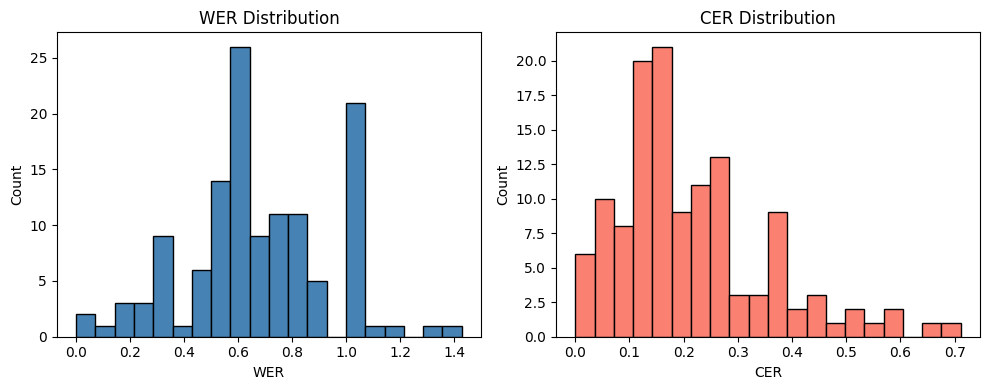

Plot saved


In [20]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(wers, bins=20, color='steelblue', edgecolor='black')
plt.title('WER Distribution')
plt.xlabel('WER')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(cers, bins=20, color='salmon', edgecolor='black')
plt.title('CER Distribution')
plt.xlabel('CER')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig(f'{save_dir}/baseline_wer_cer_distribution.png', dpi=150)
plt.show()
print('Plot saved')